In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from PIL import Image
from tqdm import tqdm

load_dotenv()
DATA_PATH = os.getenv('DATA_PATH')
IMAGE_PATH = os.getenv('IMAGE_PATH')

train_df = os.path.join(DATA_PATH, 'train.json')
val_df = os.path.join(DATA_PATH, 'val.json')

with open(train_df, 'r', encoding='utf-8') as f:
    train_data = json.load(f)

with open(val_df, 'r', encoding='utf-8') as f:
    val_data = json.load(f)

train_images = train_data.get('images', {})
val_images = val_data.get('images', {})

train_dir = os.path.join(IMAGE_PATH, 'train')
val_dir = os.path.join(IMAGE_PATH, 'val')

평가 불가 위험군 (500개 초과): 0건


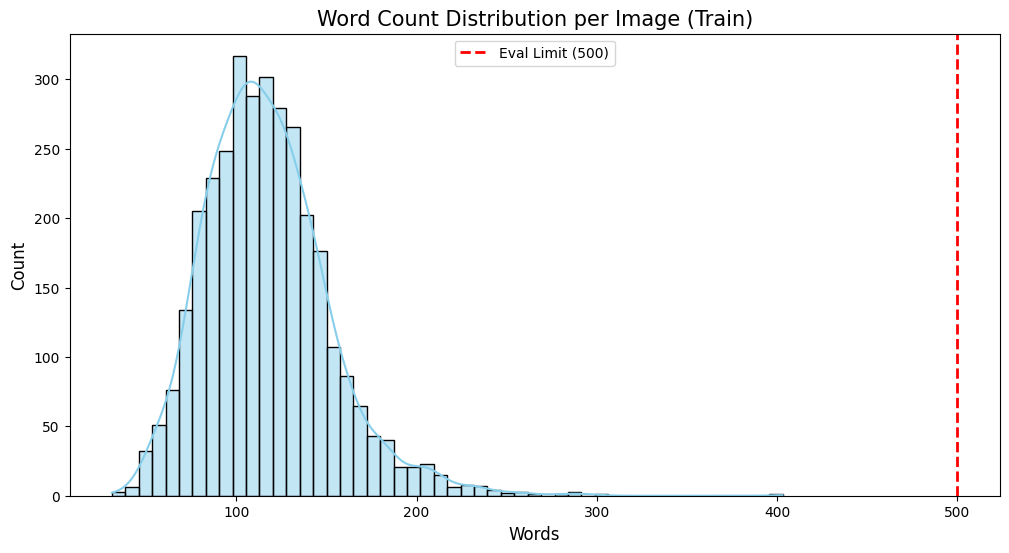

총 이미지 수: 3272


,image_name,word_count
0,drp.en_ko.in_house.selectstar_000003.jpg,89
1,drp.en_ko.in_house.selectstar_000005.jpg,99
2,drp.en_ko.in_house.selectstar_000006.jpg,57
3,drp.en_ko.in_house.selectstar_000008.jpg,162
4,drp.en_ko.in_house.selectstar_000009.jpg,142


In [2]:
# 이미지별 단어 개수 데이터프레임화 (train)
df = pd.DataFrame([
    {'image_name': name, 'word_count': len(content.get('words', {}))}
    for name, content in train_images.items()
])

# 500개 넘으면 평가 불가! 위험군 추출
danger_zone = df[df['word_count'] > 500].sort_values(by='word_count', ascending=False)

print(f"평가 불가 위험군 (500개 초과): {len(danger_zone)}건")
if not danger_zone.empty:
    display(danger_zone)

plt.figure(figsize=(12, 6))
sns.histplot(df['word_count'], kde=True, color='skyblue', bins=50)

# 평가 제한선 그리기
plt.axvline(500, color='red', linestyle='--', linewidth=2, label='Eval Limit (500)')

plt.title('Word Count Distribution per Image (Train)', fontsize=15)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.show()

print(f"총 이미지 수: {len(df)}")
df.head()

In [3]:
# 실제 이미지 파일과 JSON 목록 일치 여부 확인 (train)
json_files = set(train_data.get('images', {}).keys())

valid_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.PNG')
dir_files = set([f for f in os.listdir(train_dir) if f.endswith(valid_extensions)])

print(f"JSON 내 이미지 수: {len(json_files)}")
print(f"실제 디렉토리 내 이미지 수: {len(dir_files)}")

# JSON에는 정의되어 있으나, 실제 디렉토리에 파일이 없는 경우
missing_in_dir = json_files - dir_files

# 디렉토리에는 파일이 있으나, JSON에는 정의되어 있지 않은 경우
missing_in_json = dir_files - json_files

print(f"\n--- [체크 결과] ---")

if not missing_in_dir and not missing_in_json:
    print("✅ 모든 파일이 완벽하게 일치합니다!")
else:
    if missing_in_dir:
        print(f"\n❌ JSON에만 있고 디렉토리에는 없는 파일 ({len(missing_in_dir)}건):")
        print(list(missing_in_dir)[:10], "...등" if len(missing_in_dir) > 10 else "")

    if missing_in_json:
        print(f"\n❌ 디렉토리에만 있고 JSON에는 없는 파일 ({len(missing_in_json)}건):")
        print(list(missing_in_json)[:10], "...등" if len(missing_in_json) > 10 else "")

JSON 내 이미지 수: 3272
실제 디렉토리 내 이미지 수: 3272

--- [체크 결과] ---
✅ 모든 파일이 완벽하게 일치합니다!


평가 불가 위험군 (500개 초과): 0건


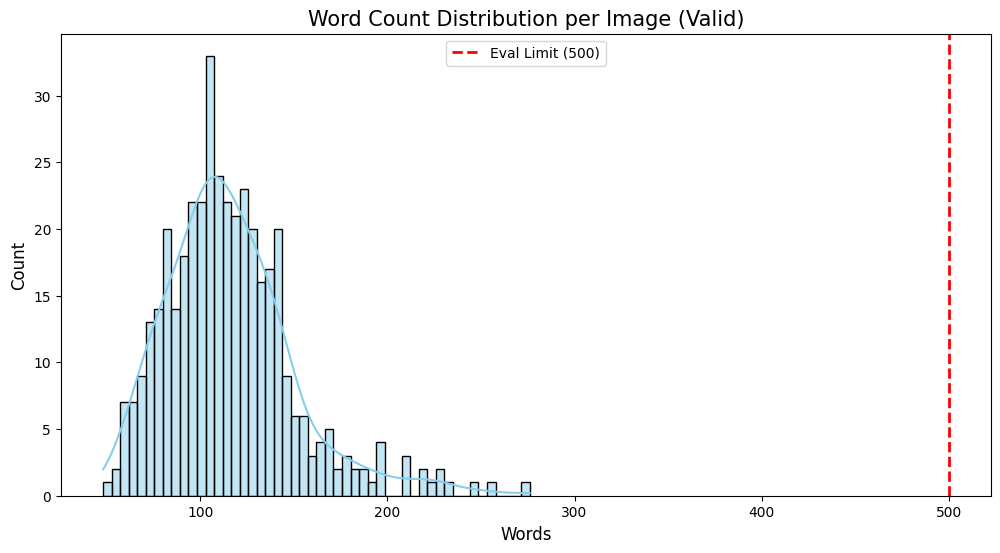

총 이미지 수: 404


,image_name,word_count
0,drp.en_ko.in_house.selectstar_000007.jpg,76
1,drp.en_ko.in_house.selectstar_000030.jpg,127
2,drp.en_ko.in_house.selectstar_000032.jpg,155
3,drp.en_ko.in_house.selectstar_000046.jpg,104
4,drp.en_ko.in_house.selectstar_000056.jpg,196


In [4]:
# 이미지별 단어 개수 데이터프레임화 (valid)
df = pd.DataFrame([
    {'image_name': name, 'word_count': len(content.get('words', {}))}
    for name, content in val_images.items()
])

# 500개 넘으면 평가 불가! 위험군 추출
danger_zone = df[df['word_count'] > 500].sort_values(by='word_count', ascending=False)

print(f"평가 불가 위험군 (500개 초과): {len(danger_zone)}건")
if not danger_zone.empty:
    display(danger_zone)

plt.figure(figsize=(12, 6))
sns.histplot(df['word_count'], kde=True, color='skyblue', bins=50)

# 평가 제한선 그리기
plt.axvline(500, color='red', linestyle='--', linewidth=2, label='Eval Limit (500)')

plt.title('Word Count Distribution per Image (Valid)', fontsize=15)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.show()

print(f"총 이미지 수: {len(df)}")
df.head()

In [5]:
# 실제 이미지 파일과 JSON 목록 일치 여부 확인 (valid)
json_files = set(val_data.get('images', {}).keys())

valid_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.PNG')
dir_files = set([f for f in os.listdir(val_dir) if f.endswith(valid_extensions)])

print(f"JSON 내 이미지 수: {len(json_files)}")
print(f"실제 디렉토리 내 이미지 수: {len(dir_files)}")

# JSON에는 정의되어 있으나, 실제 디렉토리에 파일이 없는 경우
missing_in_dir = json_files - dir_files

# 디렉토리에는 파일이 있으나, JSON에는 정의되어 있지 않은 경우
missing_in_json = dir_files - json_files

print(f"\n--- [체크 결과] ---")

if not missing_in_dir and not missing_in_json:
    print("✅ 모든 파일이 완벽하게 일치합니다!")
else:
    if missing_in_dir:
        print(f"\n❌ JSON에만 있고 디렉토리에는 없는 파일 ({len(missing_in_dir)}건):")
        print(list(missing_in_dir)[:10], "...등" if len(missing_in_dir) > 10 else "")

    if missing_in_json:
        print(f"\n❌ 디렉토리에만 있고 JSON에는 없는 파일 ({len(missing_in_json)}건):")
        print(list(missing_in_json)[:10], "...등" if len(missing_in_json) > 10 else "")

JSON 내 이미지 수: 404
실제 디렉토리 내 이미지 수: 404

--- [체크 결과] ---
✅ 모든 파일이 완벽하게 일치합니다!


Analyzing Areas: 100%|██████████| 3272/3272 [00:08<00:00, 405.72it/s]



총 분석된 박스 수: 382460
          area_ratio
count  382460.000000
mean        0.164808
std         0.217184
min         0.000181
25%         0.049453
50%         0.102214
75%         0.204771
max        14.808073


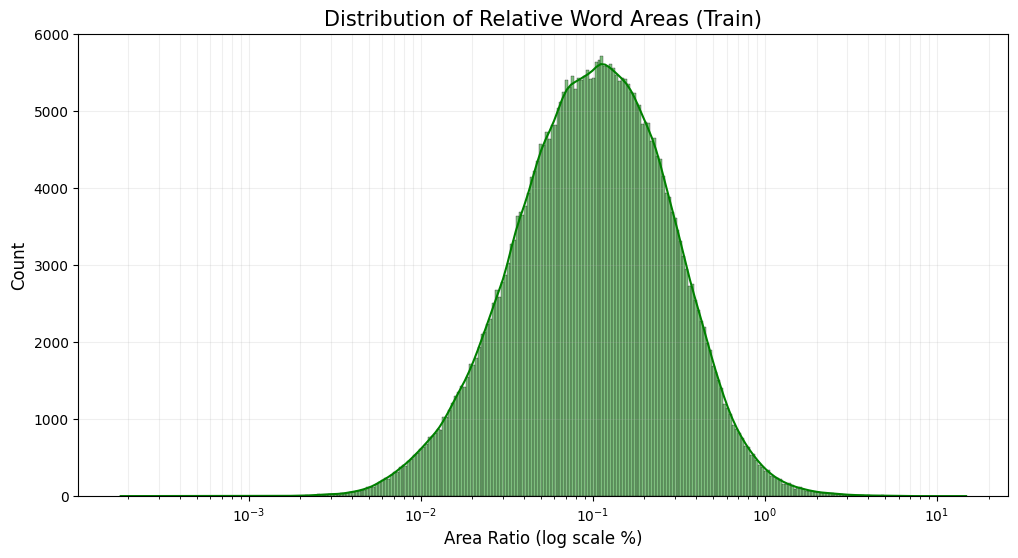

In [6]:
# 박스 크기 분포 (train)
def calculate_box_area(points):
    x = [p[0] for p in points]
    y = [p[1] for p in points]
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

area_ratios = []

for img_name, content in tqdm(train_images.items(), desc="Analyzing Areas"):
    img_path = os.path.join(train_dir, img_name)

    if not os.path.exists(img_path):
        continue

    try:
        # 실제 이미지 파일을 열어서 정확한 width, height 획득
        with Image.open(img_path) as img:
            img_w, img_h = img.size

        img_total_area = img_w * img_h
        if img_total_area == 0: continue

        words = content.get('words', {})
        for word_id, word_info in words.items():
            points = word_info.get('points', [])

            if len(points) >= 4:
                box_area = calculate_box_area(points)

                # min: 0.000000은 좌표가 찍혀있지만 면적이 없는(점이나 선 형태) 박스들이 존재한다는 의미!
                # 유효한 면적(0보다 큰 경우)만 리스트에 추가
                if box_area > 0:
                    # 이미지 실제 면적 대비 박스 면적 비율 (%)
                    ratio = (box_area / img_total_area) * 100
                    if np.isfinite(ratio):
                        area_ratios.append(ratio)

    except Exception as e:
        print(f"Error at {img_name}: {e}")

area_df = pd.DataFrame(area_ratios, columns=['area_ratio'])
print(f"\n총 분석된 박스 수: {len(area_df)}")
print(area_df.describe())

plt.figure(figsize=(12, 6))
sns.histplot(area_df['area_ratio'], kde=True, color='green', log_scale=(True, False))
plt.title('Distribution of Relative Word Areas (Train)', fontsize=15)
plt.xlabel('Area Ratio (log scale %)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

Analyzing Areas: 100%|██████████| 404/404 [00:00<00:00, 417.32it/s]



총 분석된 박스 수: 46714
         area_ratio
count  46714.000000
mean       0.166123
std        0.211610
min        0.000719
25%        0.050904
50%        0.104477
75%        0.206383
max        6.411981


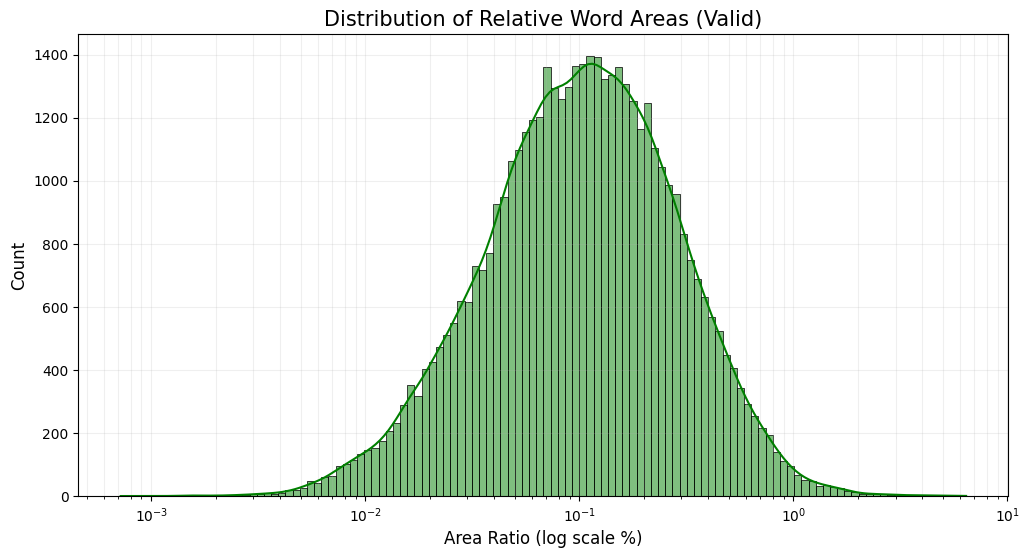

In [7]:
# 박스 크기 분포 (valid)
def calculate_box_area(points):
    x = [p[0] for p in points]
    y = [p[1] for p in points]
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

area_ratios = []

for img_name, content in tqdm(val_images.items(), desc="Analyzing Areas"):
    img_path = os.path.join(val_dir, img_name)

    if not os.path.exists(img_path):
        continue

    try:
        # 실제 이미지 파일을 열어서 정확한 width, height 획득
        with Image.open(img_path) as img:
            img_w, img_h = img.size

        img_total_area = img_w * img_h
        if img_total_area == 0: continue

        words = content.get('words', {})
        for word_id, word_info in words.items():
            points = word_info.get('points', [])

            if len(points) >= 4:
                box_area = calculate_box_area(points)

                # min: 0.000000은 좌표가 찍혀있지만 면적이 없는(점이나 선 형태) 박스들이 존재한다는 의미!
                # 유효한 면적(0보다 큰 경우)만 리스트에 추가
                if box_area > 0:
                    # 이미지 실제 면적 대비 박스 면적 비율 (%)
                    ratio = (box_area / img_total_area) * 100
                    if np.isfinite(ratio):
                        area_ratios.append(ratio)

    except Exception as e:
        print(f"Error at {img_name}: {e}")

area_df = pd.DataFrame(area_ratios, columns=['area_ratio'])
print(f"\n총 분석된 박스 수: {len(area_df)}")
print(area_df.describe())

plt.figure(figsize=(12, 6))
sns.histplot(area_df['area_ratio'], kde=True, color='green', log_scale=(True, False))
plt.title('Distribution of Relative Word Areas (Valid)', fontsize=15)
plt.xlabel('Area Ratio (log scale %)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [8]:
# train, valid 통합
# images = train_data.get('images', {}).copy()
# images.update(val_data.get('images', {}))